In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load historical index data
nse_indexes = pd.read_csv(r"C:\Users\Dell\Downloads\NIFTY\nse_indexes.csv")

# Clean columns
nse_indexes.columns = nse_indexes.columns.str.strip()

print(nse_indexes.head())
print(nse_indexes.columns)

         Date     Index     Open     High     Low   Close  Volume Currency
0  1995-11-06  NIFTY 50  1001.53  1001.53  988.92  988.92       0      INR
1  1995-11-07  NIFTY 50   987.17   987.17  977.05  978.22       0      INR
2  1995-11-08  NIFTY 50   976.28   976.28  962.98  964.01       0      INR
3  1995-11-09  NIFTY 50   960.32   960.32  952.13  953.07       0      INR
4  1995-11-10  NIFTY 50   951.93   951.93  946.00  948.82       0      INR
Index(['Date', 'Index', 'Open', 'High', 'Low', 'Close', 'Volume', 'Currency'], dtype='object')


In [3]:
# Convert Date
nse_indexes['Date'] = pd.to_datetime(nse_indexes['Date'])

# Filter NIFTY 50
nifty = nse_indexes[nse_indexes['Index'] == 'NIFTY 50'].copy()

# Sort by date
nifty = nifty.sort_values('Date')

nifty.head()

,Date,Index,Open,High,Low,Close,Volume,Currency
0,1995-11-06,NIFTY 50,1001.53,1001.53,988.92,988.92,0,INR
1,1995-11-07,NIFTY 50,987.17,987.17,977.05,978.22,0,INR
2,1995-11-08,NIFTY 50,976.28,976.28,962.98,964.01,0,INR
3,1995-11-09,NIFTY 50,960.32,960.32,952.13,953.07,0,INR
4,1995-11-10,NIFTY 50,951.93,951.93,946.00,948.82,0,INR


In [4]:
nifty['log_return'] = np.log(
    nifty['Close'] / nifty['Close'].shift(1)
)

nifty = nifty.dropna().reset_index(drop=True)

returns = nifty['log_return']

In [5]:
adf_result = adfuller(returns)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -18.32409848635861
p-value: 2.2627266401570203e-30


In [6]:
split = int(len(returns) * 0.8)

train_returns = returns.iloc[:split]

test_returns  = returns.iloc[split:]

In [7]:
arch_mod = arch_model(
    train_returns,
    mean='Zero',
    vol='ARCH',
    p=1
)

arch_res = arch_mod.fit(disp='off')
print(arch_res.summary())

                        Zero Mean - ARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                14551.4
Distribution:                  Normal   AIC:                          -29098.8
Method:            Maximum Likelihood   BIC:                          -29085.7
                                        No. Observations:                 5223
Date:                Sun, Feb 22 2026   Df Residuals:                     5223
Time:                        12:27:57   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.7375e-04  7.786e-06     22.315 2.624e-110 [1.

d:\Programs\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002442. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [8]:
garch_mod = arch_model(
    train_returns,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

garch_res = garch_mod.fit(disp='off')
print(garch_res.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                14975.4
Distribution:                  Normal   AIC:                          -29944.8
Method:            Maximum Likelihood   BIC:                          -29925.1
                                        No. Observations:                 5223
Date:                Sun, Feb 22 2026   Df Residuals:                     5223
Time:                        12:27:58   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      4.0578e-06  8.586e-11  4.726e+04      0.000 [4.

d:\Programs\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002442. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [9]:
egarch_mod = arch_model(
    train_returns,
    mean='Zero',
    vol='EGARCH',
    p=1,
    q=1
)

egarch_res = egarch_mod.fit(disp='off')
print(egarch_res.summary())

                       Zero Mean - EGARCH Model Results                       
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:                14963.6
Distribution:                  Normal   AIC:                          -29921.2
Method:            Maximum Likelihood   BIC:                          -29901.5
                                        No. Observations:                 5223
Date:                Sun, Feb 22 2026   Df Residuals:                     5223
Time:                        12:27:59   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega         -0.1870  6.427e-02     -2.909  3.621e-03 [ -0.3

d:\Programs\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002442. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [10]:
garch_forecast = garch_res.forecast(horizon=len(test_returns))
pred_vol_garch = np.sqrt(garch_forecast.variance.values[-1])

# Realized volatility
realized_vol = test_returns.rolling(20).std().dropna()

pred_vol_garch = pred_vol_garch[:len(realized_vol)]

In [11]:
rmse_garch = np.sqrt(mean_squared_error(realized_vol, pred_vol_garch))
mae_garch  = mean_absolute_error(realized_vol, pred_vol_garch)

print("GARCH RMSE:", rmse_garch)
print("GARCH MAE:", mae_garch)

GARCH RMSE: 0.010467320028287087
GARCH MAE: 0.009525056306970415


In [12]:
df = nifty.copy()

df['vol_5']  = df['log_return'].rolling(5).std()
df['vol_20'] = df['log_return'].rolling(20).std()
df['ewma_vol'] = df['log_return'].ewm(span=20).std()

df['ret_lag1'] = df['log_return'].shift(1)
df['ret_lag2'] = df['log_return'].shift(2)

df['target'] = df['vol_20'].shift(-1)

df = df.dropna().reset_index(drop=True)

In [13]:
from xgboost import XGBRegressor

features = [
    'ret_lag1','ret_lag2',
    'vol_5','vol_20','ewma_vol'
]

X = df[features]
y = df['target']

split_ml = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_ml], X.iloc[split_ml:]
y_train, y_test = y.iloc[:split_ml], y.iloc[split_ml:]

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAE:", mae_xgb)

XGBoost RMSE: 0.0008701924785898226
XGBoost MAE: 0.0004430142034795277


In [14]:
lstm_features = ['log_return','vol_5','vol_20','ewma_vol']

data_lstm = df[lstm_features + ['target']]

split_lstm = int(len(data_lstm) * 0.8)

train_df = data_lstm.iloc[:split_lstm]
test_df  = data_lstm.iloc[split_lstm:]

In [15]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_df[lstm_features])
X_test_scaled  = scaler_X.transform(test_df[lstm_features])

y_train_scaled = scaler_y.fit_transform(train_df[['target']])
y_test_scaled  = scaler_y.transform(test_df[['target']])

In [16]:
def create_sequences(X, y, window=20):
    X_seq, y_seq = [], []
    for i in range(window, len(X)):
        X_seq.append(X[i-window:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train_scaled)
X_test_lstm, y_test_lstm   = create_sequences(X_test_scaled, y_test_scaled)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

Epoch 1/20


d:\Programs\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0050 - val_loss: 9.9951e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0022 - val_loss: 8.0786e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020 - val_loss: 7.1625e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018 - val_loss: 7.6780e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 7.5154e-04
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 6.4751e-04
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 6.8639e-04
Epoch 9/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 6.0067e-04
Epoch 10/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 6.3319e-04
Epoch 11/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 5.4301e-04
Epoch 12/20
163/163 ━━━

In [18]:
lstm_pred_scaled = model.predict(X_test_lstm)

lstm_pred = scaler_y.inverse_transform(lstm_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_lstm)

rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
mae_lstm  = mean_absolute_error(y_test_actual, lstm_pred)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
LSTM RMSE: 0.0013307562833448474
LSTM MAE: 0.0010786176483106255


In [19]:
final_results = pd.DataFrame({
    'Model': ['GARCH', 'XGBoost', 'LSTM'],
    'RMSE': [rmse_garch, rmse_xgb, rmse_lstm],
    'MAE':  [mae_garch, mae_xgb, mae_lstm]
})

final_results

,Model,RMSE,MAE
0,GARCH,0.010467,0.009525
1,XGBoost,0.000870,0.000443
2,LSTM,0.001331,0.001079


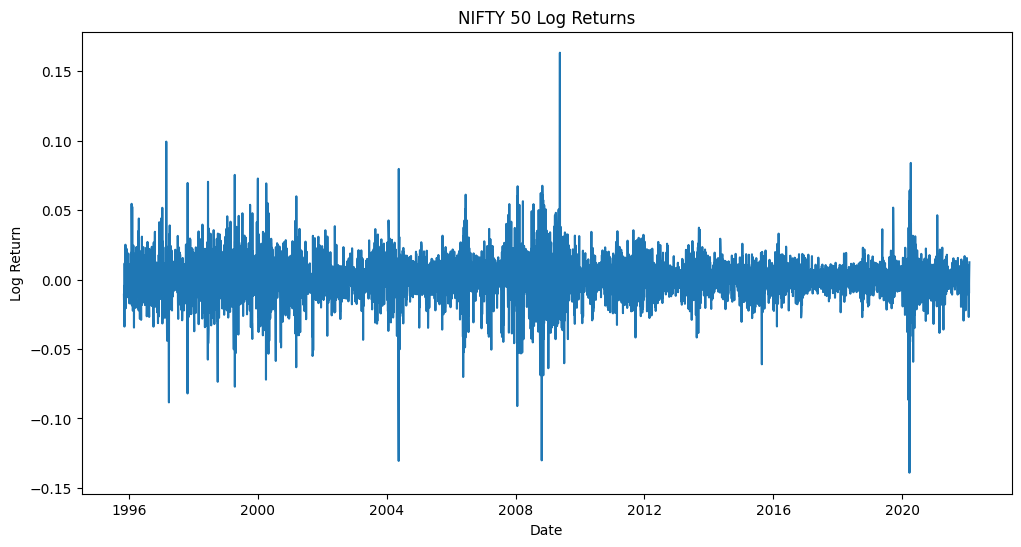

In [20]:
plt.figure(figsize=(12,6))
plt.plot(nifty['Date'], nifty['log_return'])
plt.title("NIFTY 50 Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.show()

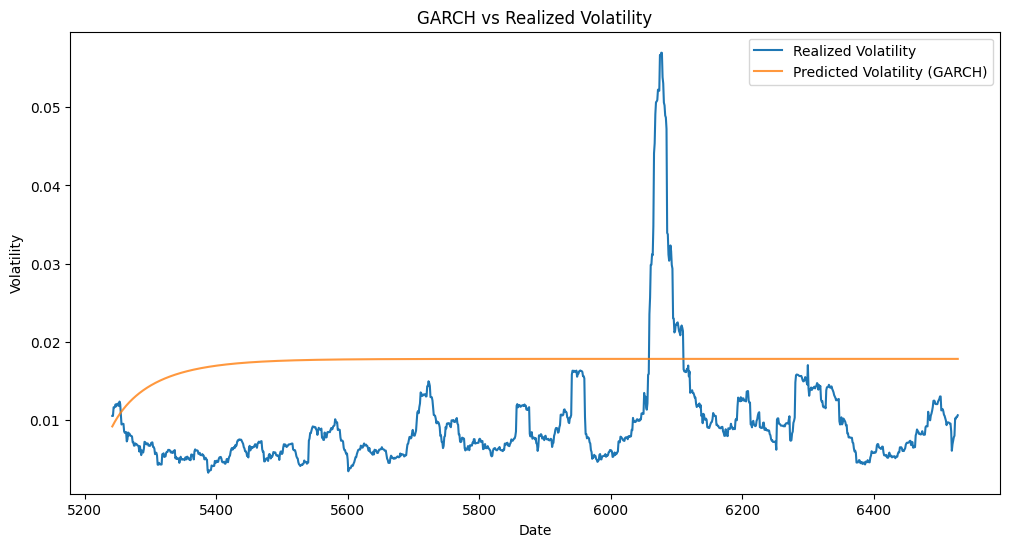

In [21]:
plt.figure(figsize=(12,6))

plt.plot(realized_vol.index, realized_vol.values, 
         label='Realized Volatility')

plt.plot(realized_vol.index, pred_vol_garch, 
         label='Predicted Volatility (GARCH)', alpha=0.8)

plt.title("GARCH vs Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

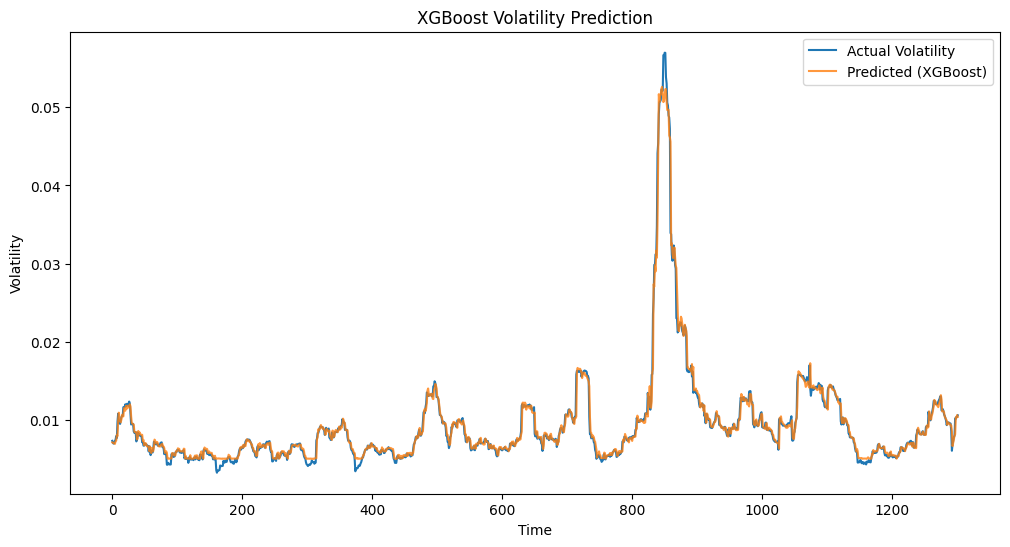

In [22]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Volatility')
plt.plot(y_pred_xgb, label='Predicted (XGBoost)', alpha=0.8)

plt.title("XGBoost Volatility Prediction")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show()

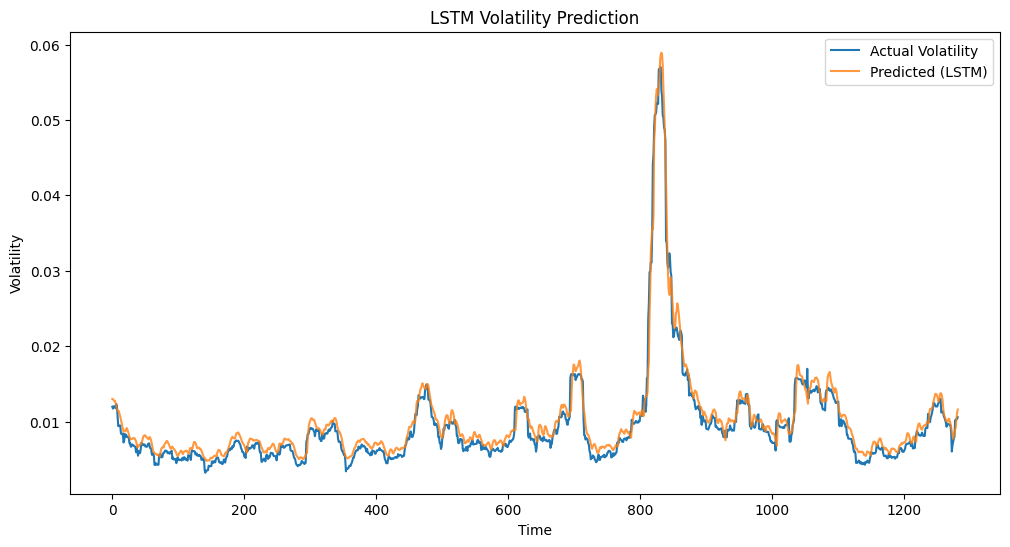

In [23]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual Volatility')
plt.plot(lstm_pred, label='Predicted (LSTM)', alpha=0.8)

plt.title("LSTM Volatility Prediction")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show()

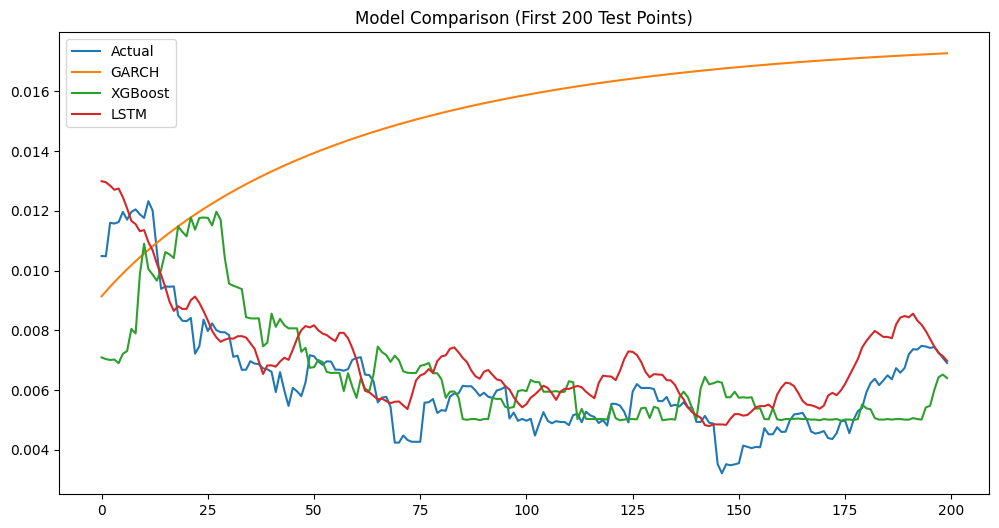

In [24]:
plt.figure(figsize=(12,6))

plt.plot(realized_vol.values[:200], label='Actual')
plt.plot(pred_vol_garch[:200], label='GARCH')
plt.plot(y_pred_xgb[:200], label='XGBoost')
plt.plot(lstm_pred[:200], label='LSTM')

plt.title("Model Comparison (First 200 Test Points)")
plt.legend()
plt.show()

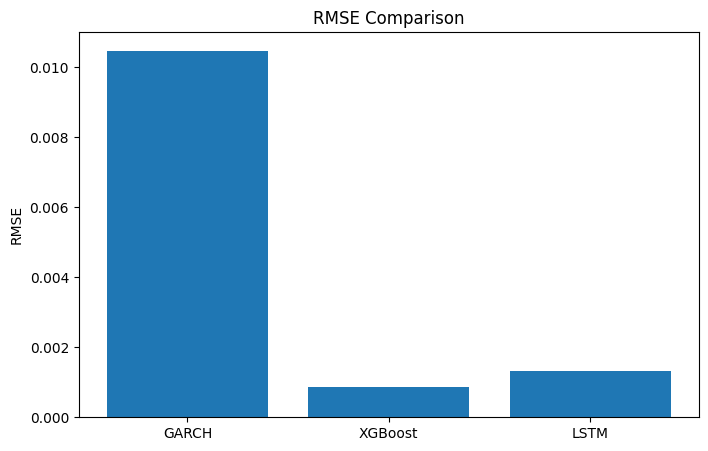

In [25]:
plt.figure(figsize=(8,5))

models = ['GARCH', 'XGBoost', 'LSTM']
rmse_values = [rmse_garch, rmse_xgb, rmse_lstm]

plt.bar(models, rmse_values)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

In [26]:
# Train volatility from GARCH
train_vol_garch = garch_res.conditional_volatility

In [27]:
garch_forecast = garch_res.forecast(start=split, horizon=1)
test_vol_garch = np.sqrt(garch_forecast.variance.iloc[split:])

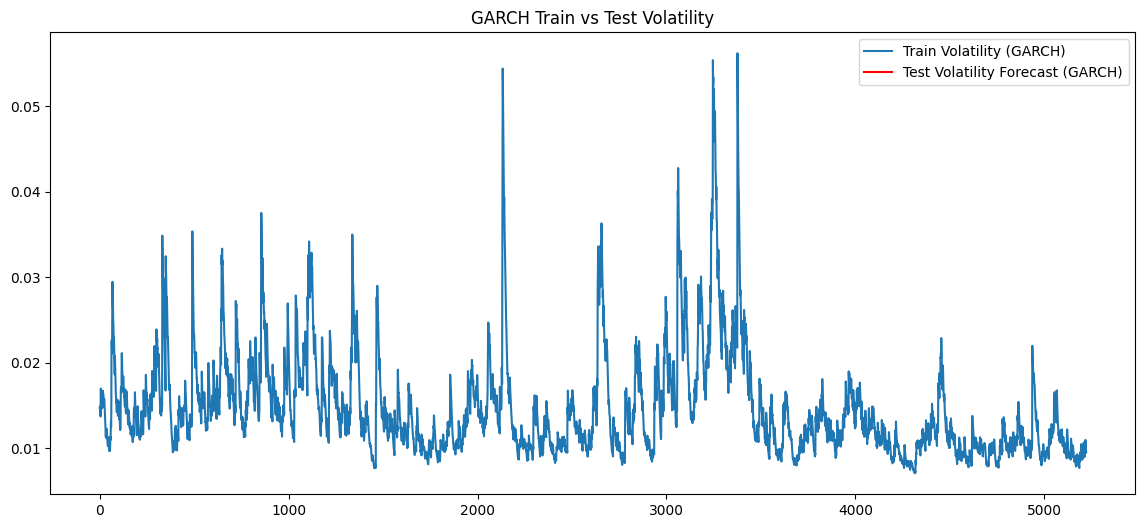

In [28]:
plt.figure(figsize=(14,6))

plt.plot(train_vol_garch, label='Train Volatility (GARCH)')
plt.plot(test_vol_garch, label='Test Volatility Forecast (GARCH)', color='red')

plt.title("GARCH Train vs Test Volatility")
plt.legend()
plt.show()

In [29]:
lstm_train_pred_scaled = model.predict(X_train_lstm)

lstm_train_pred = scaler_y.inverse_transform(lstm_train_pred_scaled)
y_train_actual = scaler_y.inverse_transform(y_train_lstm)

163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


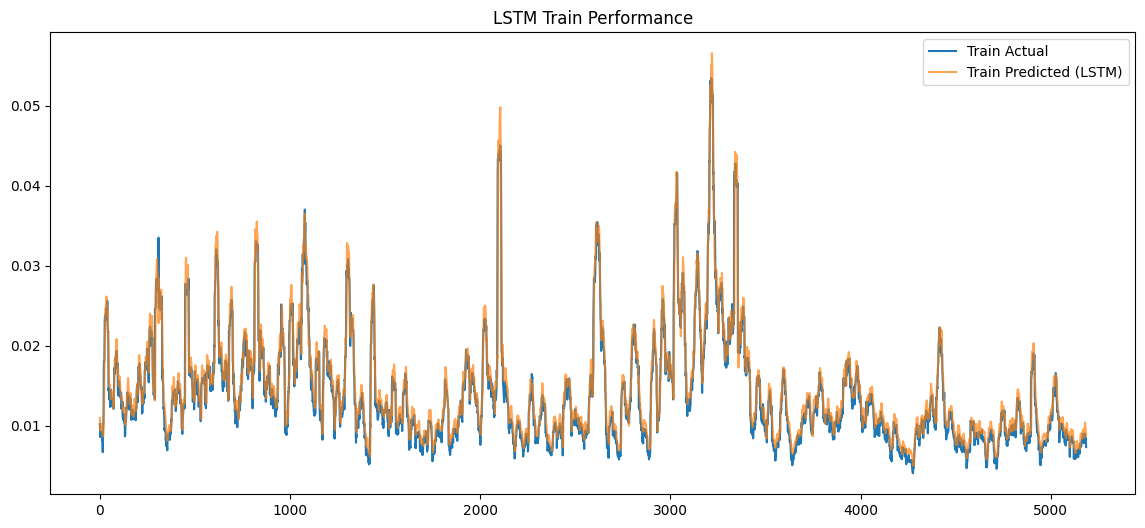

In [30]:
plt.figure(figsize=(14,6))

plt.plot(y_train_actual, label='Train Actual')
plt.plot(lstm_train_pred, label='Train Predicted (LSTM)', alpha=0.7)

plt.title("LSTM Train Performance")
plt.legend()
plt.show()

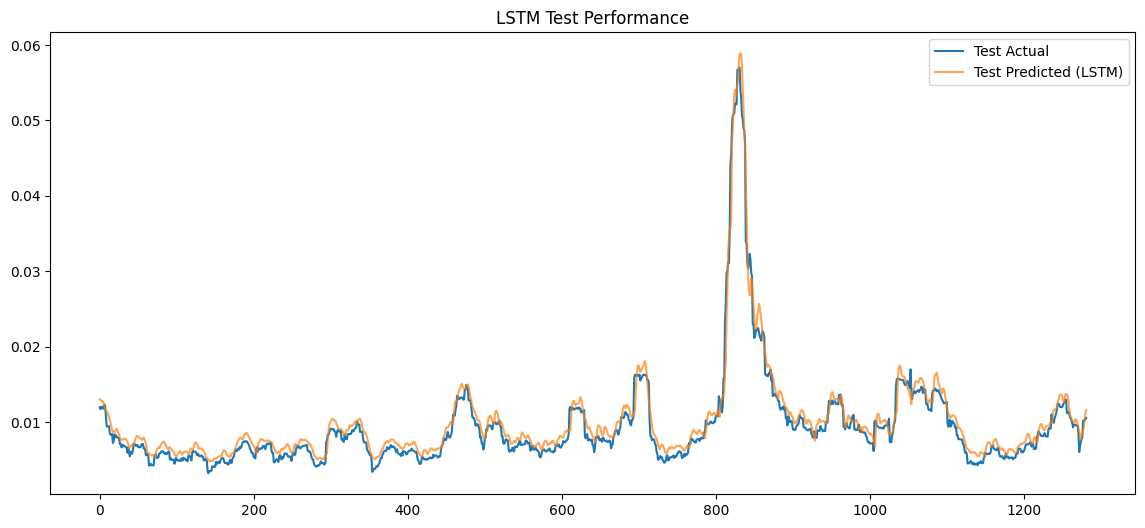

In [31]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label='Test Actual')
plt.plot(lstm_pred, label='Test Predicted (LSTM)', alpha=0.7)

plt.title("LSTM Test Performance")
plt.legend()
plt.show()

In [ ]:
# ---- Rolling One-Step GARCH Forecast ----

from arch import arch_model
import numpy as np

garch_forecasts = []

for i in range(len(test_returns)):
    
    # Expanding window training
    train_data = returns.iloc[:split + i]
    
    model = arch_model(train_data, mean='Zero', vol='GARCH', p=1, q=1)
    res = model.fit(disp='off')
    
    forecast = res.forecast(horizon=1)
    
    garch_forecasts.append(
        np.sqrt(forecast.variance.values[-1, 0])
    )

garch_forecasts = np.array(garch_forecasts)

print("GARCH Forecasts Shape:", garch_forecasts.shape)